# Tight Binding Moiré Hamiltonian Construction

In this section, we outline how a moiré tight-binding Hamiltonian is constructed from its second-quantized form to a block-matrix representation. The goal is to make clear how intralayer and interlayer hopping terms are organized and how they translate into the final Hamiltonian used for numerical calculations.

The **tight-binding Hamiltonian**  [@ashcroft1976] is a widely used model in solid-state physics and quantum chemistry to describe the electronic structure of solids — especially in crystals and layered materials. In this model, electrons are considered *localized* around atomic sites but can *hop* to neighbouring atoms. To describe such a Hamiltonian for a **Moiré system**, we use the second quantized [@bruus2004] form:

$$
H = \sum_{\alpha, \beta;\, r,r' \in L} t^1_{rr', \alpha\beta}c^{\dagger}_{r,\beta}c_{r',\alpha} 
+ \sum_{\alpha, \beta;\, r,r' \in U} t^2_{rr', \alpha\beta}d^{\dagger}_{r,\beta}d_{r',\alpha} 
+ \sum_{\alpha, \beta;\, r,r'} t^{\perp}_{rr', \alpha\beta}c^{\dagger}_{r,\beta}d_{r',\alpha} + \text{h.c.}
$$

Here, $c^{\dagger}_{r,\beta}$ and $c_{r',\alpha}$ denote the electron creation and annihilation operators at lattice sites $r$ and $r'$ in the **lower layer** ($L$), associated with orbitals $\beta$ and $\alpha$, respectively. Likewise, $d^{\dagger}_{r,\beta}$ and $d_{r',\alpha}$ are the corresponding operators in the **upper layer** ($U$).

The terms $t^1_{rr', \alpha\beta}$ and $t^2_{rr', \alpha\beta}$ represent the *intralayer hopping amplitudes*, describing electron tunneling from orbital $\alpha$ at site $r'$ to orbital $\beta$ at site $r$ within the lower and upper layers, respectively. In the special case where $r = r'$ and $\alpha = \beta$, these terms correspond to the *on-site potential*—the energy of an electron residing in a particular orbital. The *interlayer coupling* is described by $t^{\perp}_{rr', \alpha\beta}$, which governs the hopping of an electron from orbital $\alpha$ at site $r'$ in the upper layer to orbital $\beta$ at site $r$ in the lower layer.

For simplicity, consider only **nearest-neighbour hopping** with a single orbital per site (**MoirePy** can handle any arbitrary number of orbital systems). In such cases, the orbital indices $\alpha$ and $\beta$ can be omitted to simplify the notation. We can define the basis as:

$$
\Psi^{\dagger} = (c^{\dagger}_{1}, c^{\dagger}_{2}, \dots, c^{\dagger}_{n}, d^{\dagger}_{1}, d^{\dagger}_{2}, \dots, d^{\dagger}_{n})
$$

Here, $c^{\dagger}_{i} ( d^{\dagger}_{i})$ is the creation operator at site $i$ in the lower (upper) layer.

Then, the Hamiltonian takes the block matrix form:

$$
H = \Psi^{\dagger}
\begin{pmatrix}
h_{LL} & h_{LU} \\
h_{UL} & h_{UU}
\end{pmatrix}
\Psi
$$

Here, $h_{LL}$ and $h_{UU}$ are the *first-quantized* $n \times n$ Hamiltonians of the lower and upper layers, respectively. The blocks $h_{LU}$ and $h_{UL}$ represent interlayer couplings.



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, SquareLayer
## set up the bilayer moire lattice with specified parameters

ll1, ll2, ul1, ul2 = 2, 3, 3, 2

lattice = BilayerMoireLattice(
    SquareLayer, ll1, ll2, ul1, ul2,
    n1=1, n2=1, pbc=True,
)
lattice.generate_connections(inter_layer_radius=1.0)

twist angle = 0.3948 rad (22.6199 deg)
13 cells in upper lattice
13 cells in lower lattice


In [4]:
## Generate the tight-binding Hamiltonian with specified hopping parameters
tb_ham = lattice.generate_hamiltonian(
    tll=0.3,
    tuu=0.3,
    tul=1.0,
    tlu=1.0,
    tuself=0.1,
    tlself=0.1,
    data_type=np.float64,  # default is np.complex128
).toarray()  # convert to dense array for visualization purposes

print("Hamiltonian shape:", tb_ham.shape)

Hamiltonian shape: (26, 26)


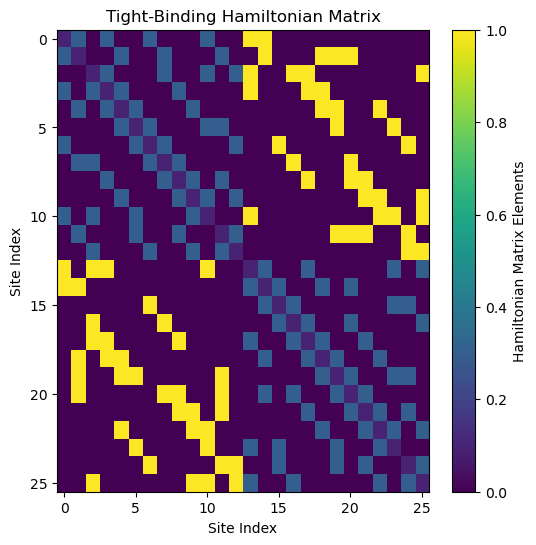

In [5]:
## Visualize the Hamiltonian in the block form
plt.figure(figsize=(6, 6))
plt.imshow(tb_ham, cmap='viridis', aspect='auto')
plt.colorbar(label='Hamiltonian Matrix Elements')
plt.title('Tight-Binding Hamiltonian Matrix')
plt.xlabel('Site Index')
plt.ylabel('Site Index')
plt.show()

Hurrah! The Hamiltonian now appears in the familiar block-matrix form. From here, you can explore a wide range of analyses as discussed in the Getting Started section.

## References

1. Neil Ashcroft, and David Mermin, Solid State Physics, Saunders College Publishing, 1976.

2. H. Bruus and K. Flensberg, Many-Body Quantum Theory in Condensed Matter Physics: An Introduction, OUP Oxford, 2004.